In [5]:
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score

In [6]:
DATA_DIR = "data/processed"
MODEL_DIR = "models/deep_learning"
os.makedirs(MODEL_DIR, exist_ok=True)
 
RANDOM_SEED = 42
BATCH_SIZE = 256
MAX_EPOCHS = 100
PATIENCE = 8            # early stopping patience (epochs w/o val PR-AUC improvement)
LEARNING_RATE = 1e-3
 
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

train_df = pd.read_csv(f"{DATA_DIR}/model_train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/model_val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/model_test.csv")


In [7]:
numeric_features = train_df.drop(columns=["Class"]).select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_df.drop(columns=["Class"]).select_dtypes(include=[object]).columns.tolist()
 
numeric_pipeline = Pipeline([("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
 
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])
 
# Fit ONLY on train, transform all three splits (no leakage)
X_train = preprocessor.fit_transform(train_df.drop(columns=["Class"])).astype(np.float32)
X_val = preprocessor.transform(val_df.drop(columns=["Class"])).astype(np.float32)
X_test = preprocessor.transform(test_df.drop(columns=["Class"])).astype(np.float32)
 
y_train = train_df["Class"].to_numpy().astype(np.float32)
y_val = val_df["Class"].to_numpy().astype(np.float32)
y_test = test_df["Class"].to_numpy().astype(np.float32)

joblib.dump(preprocessor, f"{MODEL_DIR}/mlp_preprocessor.pkl")

C:\Users\lina ahmed\AppData\Local\Temp\ipykernel_21064\2770686583.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train_df.drop(columns=["Class"]).select_dtypes(include=[object]).columns.tolist()


['models/deep_learning/mlp_preprocessor.pkl']

In [8]:
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
# weight the fraud class inversely to its frequency, same idea as pos_weight in the torch version
class_weight = {0: 1.0, 1: float(n_neg / n_pos)}
print("class_weight:", class_weight)
 
def build_model(input_dim, hidden_dims=(64, 32, 16), dropout=0.3):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for h in hidden_dims:
        x = keras.layers.Dense(h, activation="relu")(x)
        x = keras.layers.Dropout(dropout)(x)
    outputs = keras.layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs)
 
model = build_model(input_dim=X_train.shape[1])
 
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(curve="PR", name="pr_auc")],
)
 
model.summary()

class_weight: {0: 1.0, 1: 541.6448364257812}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 39)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,185 (20.25 KB)

 Trainable params: 5,185 (20.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", mode="max", patience=PATIENCE, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc", mode="max", factor=0.5, patience=3
    ),
]


In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/100
776/776 - 12s - 15ms/step - loss: 1.0791 - pr_auc: 0.3677 - val_loss: 0.1831 - val_pr_auc: 0.8491 - learning_rate: 0.0010
Epoch 2/100
776/776 - 2s - 2ms/step - loss: 0.5100 - pr_auc: 0.4962 - val_loss: 0.1505 - val_pr_auc: 0.8438 - learning_rate: 0.0010
Epoch 3/100
776/776 - 1s - 1ms/step - loss: 0.3827 - pr_auc: 0.4813 - val_loss: 0.1111 - val_pr_auc: 0.7425 - learning_rate: 0.0010
Epoch 4/100
776/776 - 1s - 1ms/step - loss: 0.3321 - pr_auc: 0.5248 - val_loss: 0.0773 - val_pr_auc: 0.8211 - learning_rate: 0.0010
Epoch 5/100
776/776 - 1s - 1ms/step - loss: 0.3183 - pr_auc: 0.5483 - val_loss: 0.0933 - val_pr_auc: 0.7263 - learning_rate: 5.0000e-04
Epoch 6/100
776/776 - 1s - 1ms/step - loss: 0.2705 - pr_auc: 0.5564 - val_loss: 0.0818 - val_pr_auc: 0.7972 - learning_rate: 5.0000e-04
Epoch 7/100
776/776 - 1s - 1ms/step - loss: 0.2808 - pr_auc: 0.5551 - val_loss: 0.0841 - val_pr_auc: 0.7158 - learning_rate: 5.0000e-04
Epoch 8/100
776/776 - 1s - 1ms/step - loss: 0.2283 - pr_auc: 0

In [11]:
val_probs = model.predict(X_val, batch_size=BATCH_SIZE).ravel()
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
 
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = float(thresholds[best_idx])
print(f"Chosen threshold (best val F1): {best_threshold:.4f}")
 
test_probs = model.predict(X_test, batch_size=BATCH_SIZE).ravel()
test_preds = (test_probs >= best_threshold).astype(int)
 
test_pr_auc = average_precision_score(y_test, test_probs)
test_f1 = f1_score(y_test, test_preds)
test_recall = (test_preds[y_test == 1] == 1).mean()
test_precision = (y_test[test_preds == 1] == 1).mean()
 
print(f"Test PR-AUC: {test_pr_auc:.4f}")
print(f"Test F1 @ chosen threshold: {test_f1:.4f}")


167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
Chosen threshold (best val F1): 0.9322
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step
Test PR-AUC: 0.7481
Test F1 @ chosen threshold: 0.8211


In [ ]:
model.save(f"{MODEL_DIR}/mlp_model.keras")
with open(f"{MODEL_DIR}/mlp_threshold.txt", "w") as f:
    f.write(str(best_threshold))
 
mlp_result = pd.DataFrame({
    "Model": ["MLP"],
    "Recall": [test_recall],
    "Precision": [test_precision],
    "F1 Score": [test_f1],
    "PR AUC": [test_pr_auc],
})
mlp_result.to_csv(f"{MODEL_DIR}/mlp_results.csv", index=False)
print(mlp_result)


  Model  Recall  Precision  F1 Score    PR AUC
0   MLP    0.75   0.906977  0.821053  0.748132


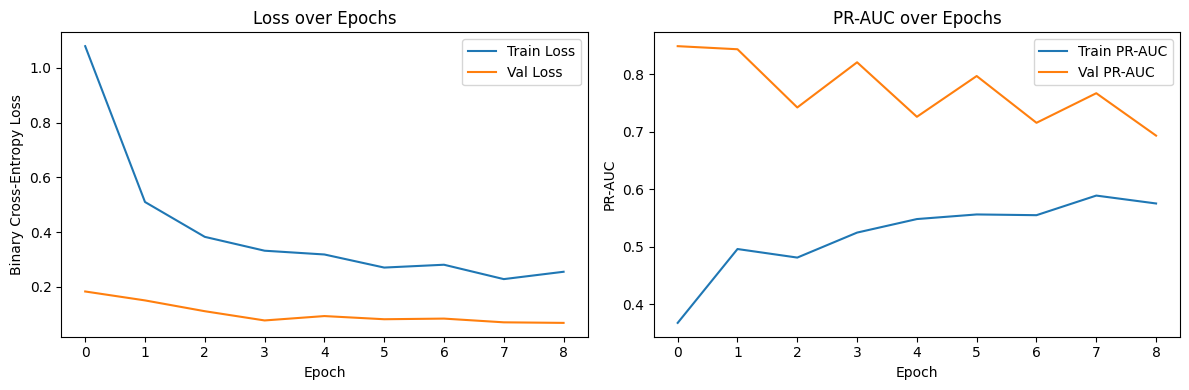

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(history.history['pr_auc'], label='Train PR-AUC')
axes[1].plot(history.history['val_pr_auc'], label='Val PR-AUC')
axes[1].set_title('PR-AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PR-AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/mlp_training_curves.png", dpi=150)
plt.show()

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     42507
       Fraud       0.91      0.75      0.82        52

    accuracy                           1.00     42559
   macro avg       0.95      0.87      0.91     42559
weighted avg       1.00      1.00      1.00     42559



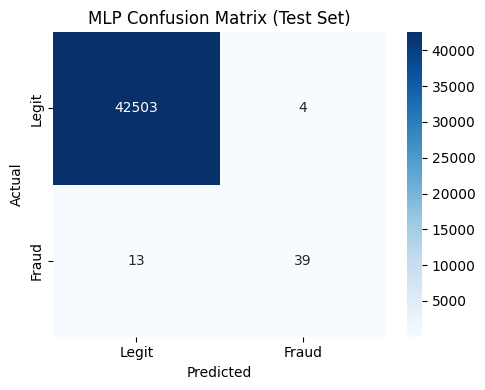

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(classification_report(y_test, test_preds, target_names=['Legit', 'Fraud']))

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('MLP Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/mlp_confusion_matrix.png", dpi=150)
plt.show()